# Boreal polar map of vegetation height for ORNL DAAC  
Paul Montesano, Ph.D.  
April 2026

In [1]:
library(aws.s3)
#library(rgdal)
library(raster)
library(tidyverse)
library(dplyr)
library(grid)
library(gridExtra)
library(RColorBrewer)
library(data.table)

library(fs)
library(sf)
#library(rgdal)

library(rgeos) # needed for fortify_sf
library(mapproj)
#library(rgee)
library(viridis)
#library(wesanderson)
library(scales)
library(tools)
library(patchwork)

library(rnaturalearth)
library(rnaturalearthdata)

Loading required package: sp

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks raster::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ dplyr::select()  masks raster::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, 

In [2]:
source('/projects/code/3dsi/boreal_map_functions.R') 

[1] "MAAP"
[1] "MAAP"


## Set output figure dir.

In [3]:
OUT_FIGURE_DIR = '/projects/my-public-bucket/boreal_HT/paper_figs'
dir.create(OUT_FIGURE_DIR)

Warning message in dir.create(OUT_FIGURE_DIR):
“'/projects/my-public-bucket/boreal_AGB/paper_figs' already exists”


#### Figure export function

In [4]:
EXPORT_MAPS_PNG_PDF <- function(m_plot_figure, OUT_FIGURE_DIR, DATA_NAME_STEM, VAR, EXPORT_TIME_STR=format(Sys.time(), "_%Y%m%d"), FIG_DIMS=c(8,16)){
    
    for(OUT_TYPE in c('png', 'pdf')){
        
        map_fn = path(OUT_FIGURE_DIR, paste0("map_",DATA_NAME_STEM,"_", VAR, EXPORT_TIME_STR,".", OUT_TYPE))
        print(map_fn)
        
        ggsave(plot = m_plot_figure,
               file = map_fn,
               device = OUT_TYPE, dpi = 300, width=FIG_DIMS[1], height=FIG_DIMS[2])
    }
}

#### Get all tiles delivered to DAAC for this project

In [5]:
boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'
boreal_tiles_gcs_DAAC = st_read(boreal_tile_DAAC_path) %>% st_transform(4326)
boreal_tile_num_DAAC_list =  boreal_tiles_gcs_DAAC %>% as.data.frame() %>% dplyr::select(tile_num) %>% as.list()
boreal_tile_num_DAAC_list = unlist(boreal_tile_num_DAAC_list[[1]])
length(boreal_tile_num_DAAC_list)

Reading layer `boreal_tiles_v004_AGB_H30_2020_ORNLDAAC' from data source 
  `/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg' 
  using driver `GPKG'
Simple feature collection with 3902 features and 3 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 43.75195 xmax: 180 ymax: 78.53133
Geodetic CRS:  WGS 84


[1] 3902

#### Get all the vegetation height rasters associated with tiles delivered to DAAC

In [48]:
# Read the tindex from s3
GPKG_FN = 's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/BOREAL_MAP/v3.1.0/Ht_H30_2020/full_run/HT_tindex_master.gpkg'
boreal_tiles_height <- aws.s3::s3read_using(st_read, object = GPKG_FN) %>% st_transform(4326)

boreal_tiles_height_DAAC = boreal_tiles_height %>% dplyr::filter(tile_num %in% boreal_tile_num_DAAC_list)

Reading layer `HT_tindex_master' from data source 
  `/tmp/RtmphO5RBc/fileb78745691bd.gpkg' using driver `GPKG'
Simple feature collection with 4949 features and 6 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -6111478 ymin: 1233304 xmax: 6308522 ymax: 10323300
Projected CRS: unnamed


In [33]:
dim(boreal_tiles_height)

[1] 4949    7

In [49]:
dim(boreal_tiles_height_DAAC)

[1] 3901    7

### Look at the tindex for the COGs

Note:
+ v3.1 is in Ali's dps_output
+ they were produced in August 2025
+ n = 3901 tiles

In [54]:
head(boreal_tiles_height_DAAC)

,tile_num,tile_version,tile_group,map_version,s3_path,local_path,geom
,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<POLYGON [°]>
1,3543,version 1,north america west,none,s3://maap-ops-workspace/aliz237/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/01/56/204100/boreal_ht_2020_202508201755722400_0003543.tif,/projects/my-private-bucket/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/01/56/204100/boreal_ht_2020_202508201755722400_0003543.tif,POLYGON ((-167.352 66.74321...
2,2673,version 1,north america west,none,s3://maap-ops-workspace/aliz237/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/12/34/298965/boreal_ht_2020_202508201755722435_0002673.tif,/projects/my-private-bucket/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/12/34/298965/boreal_ht_2020_202508201755722435_0002673.tif,POLYGON ((-122.8121 66.1030...
3,844,version 1,north america east,none,s3://maap-ops-workspace/aliz237/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/14/37/321452/boreal_ht_2020_202508201755722355_0000844.tif,/projects/my-private-bucket/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/14/37/321452/boreal_ht_2020_202508201755722355_0000844.tif,POLYGON ((-65.65852 49.9655...
4,2752,version 1,north america west,none,s3://maap-ops-workspace/aliz237/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/15/35/314752/boreal_ht_2020_202508201755722436_0002752.tif,/projects/my-private-bucket/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/15/35/314752/boreal_ht_2020_202508201755722436_0002752.tif,POLYGON ((-127.0828 66.7252...
5,1837,version 1,eurasia central,none,s3://maap-ops-workspace/aliz237/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/16/21/271029/boreal_ht_2020_202508201755722408_0001837.tif,/projects/my-private-bucket/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/16/21/271029/boreal_ht_2020_202508201755722408_0001837.tif,"POLYGON ((98.13146 67.3046,..."
6,3251,version 1,eurasia east,none,s3://maap-ops-workspace/aliz237/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/16/50/647713/boreal_ht_2020_202508201755722352_0003251.tif,/projects/my-private-bucket/dps_output/run_boreal_biomass_map/v3.1.0/Ht_H30_2020/full_run/2025/08/20/14/16/50/647713/boreal_ht_2020_202508201755722352_0003251.tif,POLYGON ((149.9531 67.07296...


In [60]:
boreal_tiles_height_DAAC = boreal_tiles_height_DAAC %>% 
        select(tile_num, s3_path, geom) %>%
        mutate(filename = basename(s3_path))

In [63]:
dim(boreal_tiles_height_DAAC)

[1] 3901    4

In [62]:
st_write(boreal_tiles_height_DAAC, '/projects/my-public-bucket/boreal_HT/DAAC/boreal_tiles_height_DAAC.gpkg')

Writing layer `boreal_tiles_height_DAAC' to data source 
  `/projects/my-public-bucket/boreal_HT/DAAC/boreal_tiles_height_DAAC.gpkg' using driver `GPKG'
Writing 3901 features with 3 fields and geometry type Polygon.


### Look at a companion `*_train.parquet` file

In [43]:
library(arrow)


Attaching package: ‘arrow’


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked from ‘package:raster’:

    buffer


The following object is masked from ‘package:utils’:

    timestamp




In [44]:
z = aws.s3::s3read_using(read_parquet, object='s3://nasa-maap-data-store/file-staging/nasa-map/icesat2-boreal-v3.1/ht/0030507/boreal_ht_2020_202508221755888663_0030507_train.parquet')

In [45]:
head(z)

lon,lat,segment_landcover,RH_98,RH_25,RH_50,RH_60,RH_70,RH_75,RH_80,RH_85,RH_90,RH_95,AGB,SE,model_id
<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
47.60362,51.71466,30,2.0863876,1.0541267,1.0541267,1.0541267,2.0322304,2.0322304,2.0322304,2.0322304,2.0322304,2.0322304,2.4996456,0.001075272,m8
47.60357,51.71438,30,0.5782661,0.5782661,0.5782661,0.5782661,0.5782661,0.5782661,0.5782661,0.5782661,0.5782661,0.5782661,0.8909509,0.001075272,m8
47.60353,51.71413,30,0.1269875,0.1269875,0.1269875,0.1269875,0.1269875,0.1269875,0.1269875,0.1269875,0.1269875,0.1269875,0.4423260,0.001075272,m8
47.60015,51.69235,30,0.3246994,0.3246994,0.3246994,0.3246994,0.3246994,0.3246994,0.3246994,0.3246994,0.3246994,0.3246994,0.6198585,0.001075272,m8
47.60011,51.69208,30,4.7907143,0.9986343,0.9986343,1.9800377,1.9800377,2.9258919,2.9258919,2.9258919,3.8922729,3.8922729,7.4740591,0.001075272,m8
47.60007,51.69181,30,2.8946800,0.8782616,0.8782616,0.8782616,1.7697258,2.8946800,2.8946800,2.8946800,2.8946800,2.8946800,3.2379406,0.001075272,m8


## Map showing boreal tile extent

In [12]:
boreal_ext = extent(-180,180,45,90)

In [51]:
#boreal_tiles_gcs = shp_fort_join(boreal_tile_index_path, ext, REPROJECT=TRUE)
dim(boreal_tiles_height_DAAC)

[1] 3901    7

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons


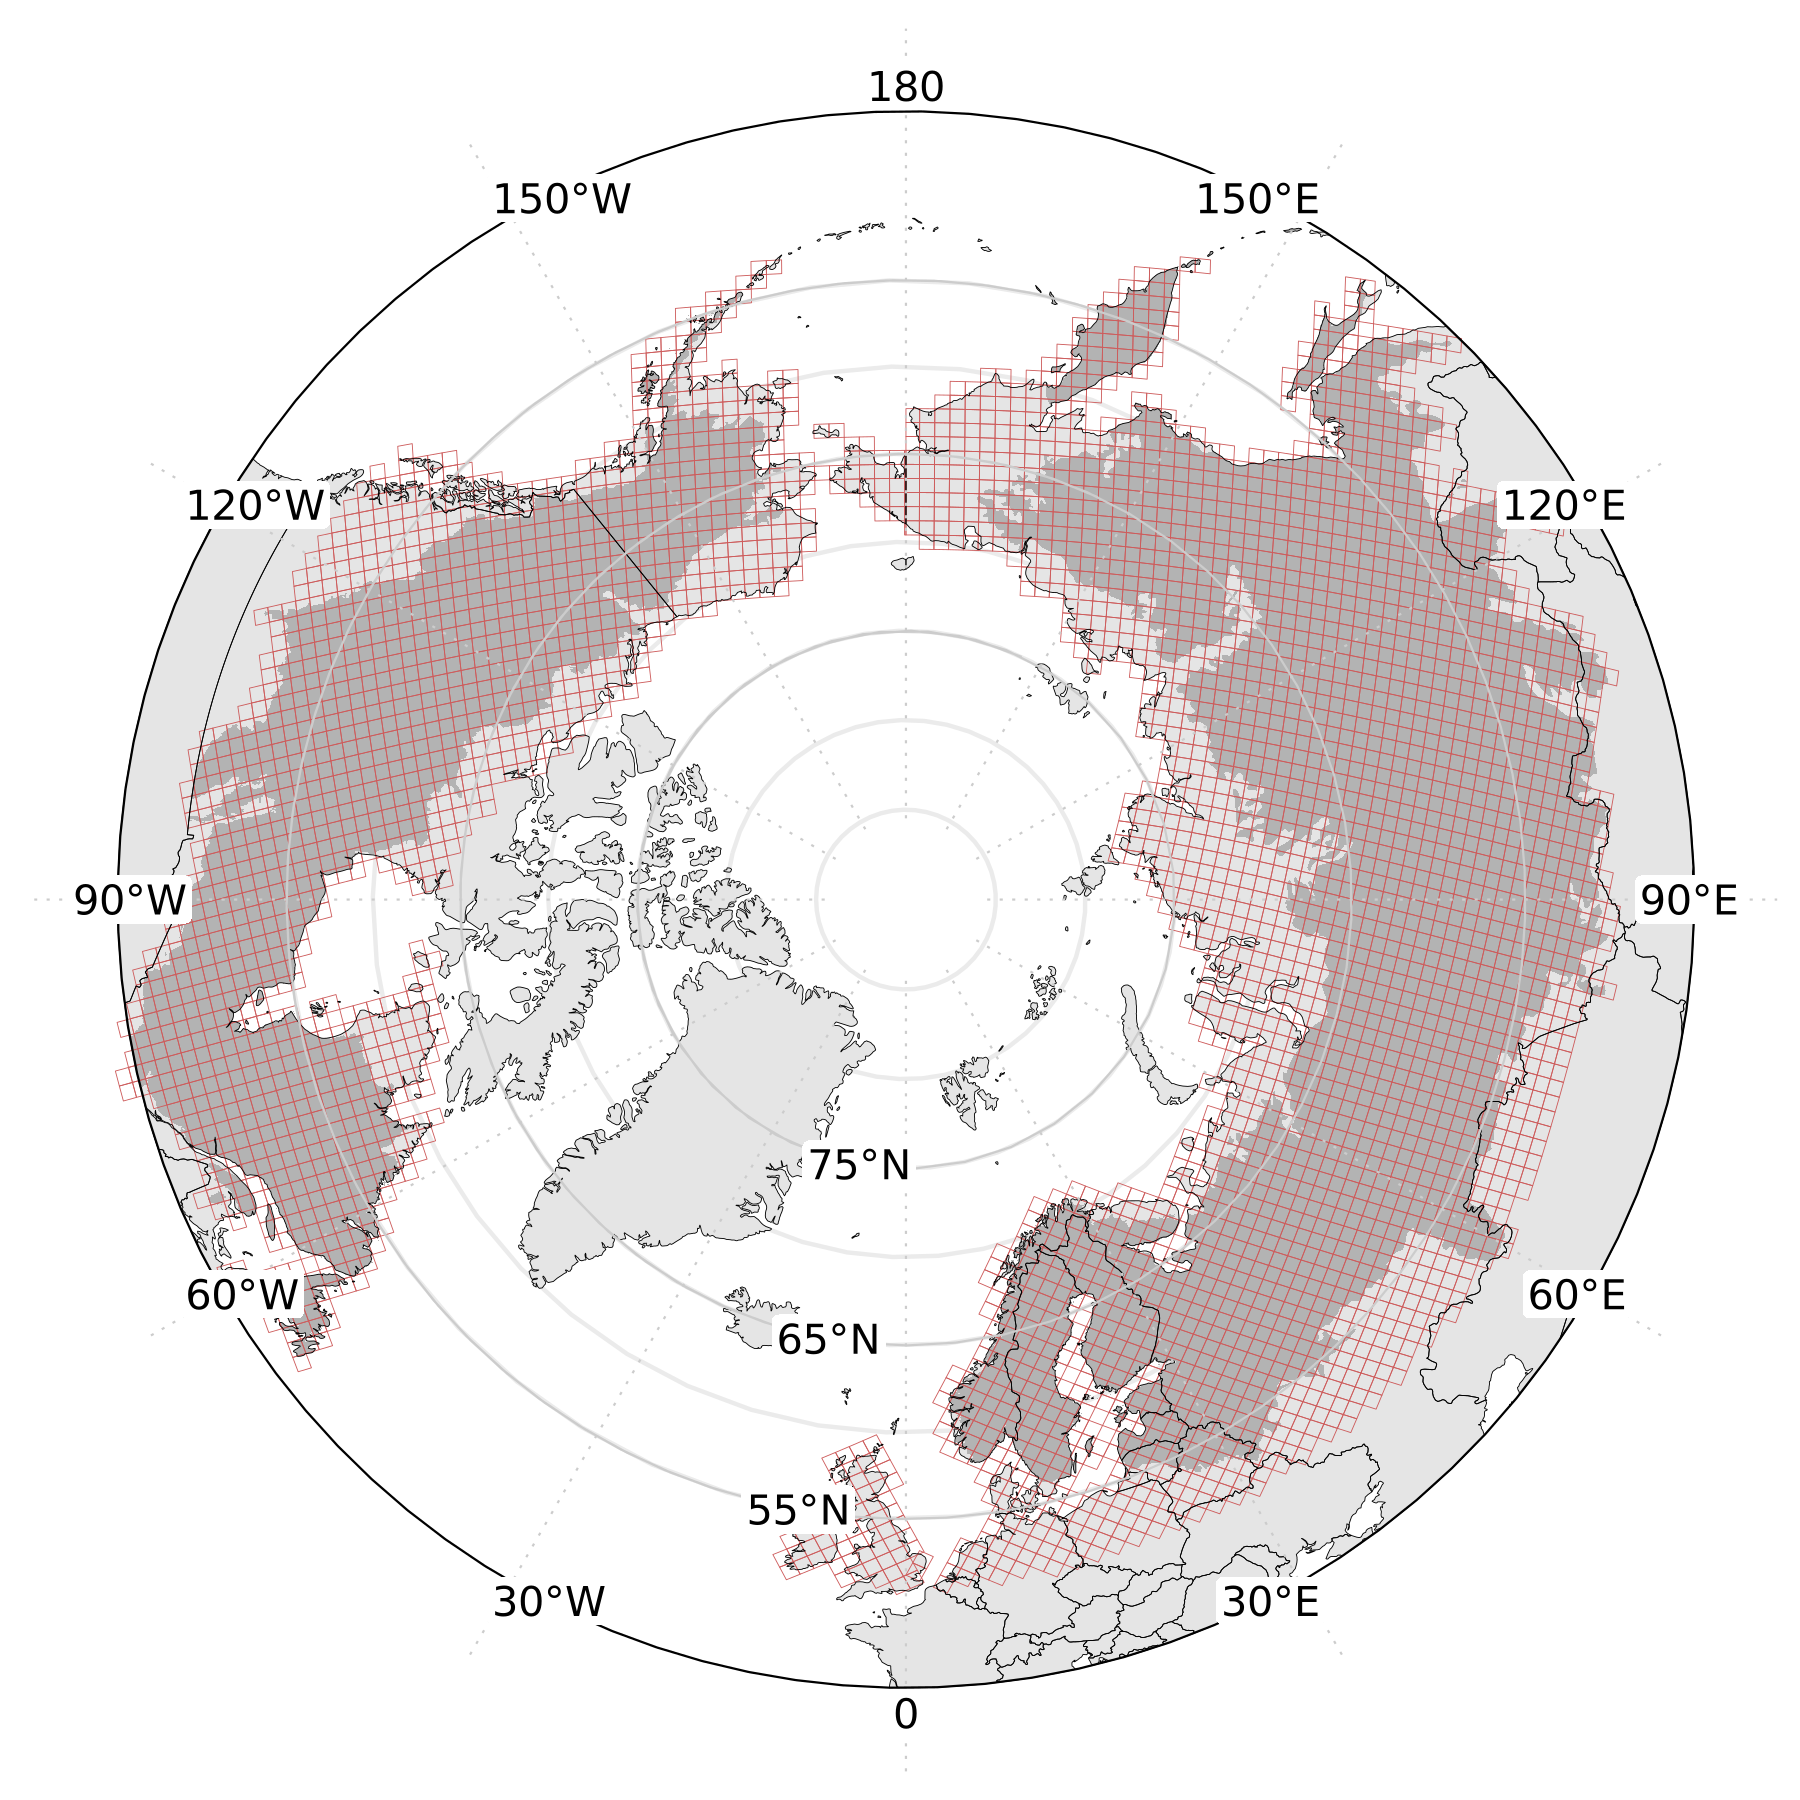

In [39]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 300)

m_DAAC_tiles = DO_MAP_BOREAL_SP(MAP_EXTENT=boreal_ext,  
                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                     LAYER_LIST = list(
                             geom_polygon(data = fortify_sf(boreal_tiles_height_DAAC), 
                                                    aes(x = long, y = lat, group = group), size=0.1, fill=NA, color='indian red')
                                      ) #, fill=NA
                    ) + 
    theme(legend.text=element_text(size=rel(0.5))) #+
    #labs(caption = paste0('n tiles = ', length(boreal_tile_num_DAAC_list)))
    #scale_color_brewer(palette = 'Set2') +
    #scale_fill_viridis_d() +
    #guides(fill=guide_legend(title="Tile groups", title.position = "top", label.position = "bottom", keywidth = unit(.5, "cm"), keyheight = unit(.25, "cm"), nrow=2))
m_DAAC_tiles

# Height tile summaries

### Note:  
Model `stats.Rds` for `dev_v1.5` and `v3.0.0` come from a single (the first) rF model - *this does NOT show model ensemble results*


### Note:  
See `code/maap_tools/notebooks/boreal_polar_map_height_summary.ipynb` for how veg height summaries were done here for earlier versions
